## Imports and stting functions

In [1]:
# @title Imports
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import time
from torch.optim.optimizer import Optimizer
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import math



In [2]:
# @title Data Loader
print("Loading Data...")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
x_train = train_data.data
image_size = x_train.shape[1] * x_train.shape[2]
x_train = x_train.reshape(-1, image_size).float() / 255

Loading Data...


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.9MB/s]


In [3]:
# @title AutoEncoder
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(image_size, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, image_size), nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [4]:
#init autoencoder
autoencoder = Autoencoder()

## oracle functions
you should use to given model, loss function and x returns either the model output, the loss, the gradient and the hessian.

In [5]:
def autoencoder_oracle(model, criterion, x, calc_hessian=False):
    """
    Computes f(x), gradient, and Hessian for a given input x.
    """
    # Forward Pass
    reconstructed_x = model(x)
    loss = criterion(reconstructed_x, x)

    grads = torch.autograd.grad(loss, model.parameters(), create_graph=calc_hessian)

    hessians = []

    if calc_hessian:
        for i, (grad, param) in enumerate(zip(grads, model.parameters())):

            grad_flat = grad.view(-1)

            hessian_rows = []
            for j in range(len(grad_flat)):

                grad_2nd = torch.autograd.grad(grad_flat[j], param, retain_graph=True)[0]
                hessian_rows.append(grad_2nd.view(-1))

            hessian_matrix = torch.stack(hessian_rows)
            hessians.append(hessian_matrix)


    return loss, grads, hessians

In [6]:
print("Initializing the model (Defining the function surface)...")
train_dataset = TensorDataset(x_train)
train_loader = DataLoader(train_dataset, batch_size=350, shuffle=True)

# This dataset is for the second order learners - so you wont run out of RAM
small_train_dataset = TensorDataset(x_train[:100]) # רק 100 תמונות להדגמה
small_train_loader = DataLoader(small_train_dataset, batch_size=10, shuffle=True)



Initializing the model (Defining the function surface)...


## Examples for optimizers

In [7]:
def gd_step(x, grad_f_x, learning_rate=0.1):
    """
    Performs one step of Gradient Descent.
    Formula: x_new = x - lr * gradient
    """
    x_new = x - learning_rate * grad_f_x

    return x_new

In [8]:
def newton_step(x, grad_f_x, hessian_f_x, learning_rate=1.0):
    """
    Performs one step of Newton-Raphson optimization on a batch.
    Shapes:
      x: (Batch, Dim)
      grad_f_x: (Batch, Dim)
      hessian_f_x: (Batch, Dim, Dim)
    """
    # 1. Calculate Inverse Hessian
    # torch.linalg.pinv handles batch dimensions automatically (Batch, D, D)
    hessian_inv = torch.linalg.pinv(hessian_f_x)

    # 2. Prepare Gradient for Batch Matrix Multiplication
    # grad_f_x is (Batch, D). We need (Batch, D, 1) for matmul
    grad_unsqueezed = grad_f_x.unsqueeze(2)

    # 3. Compute Update Direction: H^-1 * Gradient
    # (Batch, D, D) x (Batch, D, 1) -> (Batch, D, 1)
    update_direction = torch.matmul(hessian_inv, grad_unsqueezed)

    # 4. Remove extra dimension: (Batch, D, 1) -> (Batch, D)
    update_direction = update_direction.squeeze(2)

    # 5. Apply Update
    x_new = x - learning_rate * update_direction

    return x_new

**Lion Optimizer**

In [9]:
## Lion Optimizer

class Lion(Optimizer):
  r"""Implements Lion algorithm."""

  def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
    """Initialize the hyperparameters.

    Args:
      params (iterable): iterable of parameters to optimize or dicts defining
        parameter groups
      lr (float, optional): learning rate (default: 1e-4)
      betas (Tuple[float, float], optional): coefficients used for computing
        running averages of gradient and its square (default: (0.9, 0.99))
      weight_decay (float, optional): weight decay coefficient (default: 0)
    """

    if not 0.0 <= lr:
      raise ValueError('Invalid learning rate: {}'.format(lr))
    if not 0.0 <= betas[0] < 1.0:
      raise ValueError('Invalid beta parameter at index 0: {}'.format(betas[0]))
    if not 0.0 <= betas[1] < 1.0:
      raise ValueError('Invalid beta parameter at index 1: {}'.format(betas[1]))
    defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay)
    super().__init__(params, defaults)

  @torch.no_grad()
  def step(self, closure=None):
    """Performs a single optimization step.

    Args:
      closure (callable, optional): A closure that reevaluates the model
        and returns the loss.

    Returns:
      the loss.
    """
    loss = None
    if closure is not None:
      with torch.enable_grad():
        loss = closure()

    for group in self.param_groups:
      for p in group['params']:
        if p.grad is None:
          continue

        # Perform stepweight decay
        p.data.mul_(1 - group['lr'] * group['weight_decay'])

        grad = p.grad
        state = self.state[p]
        # State initialization
        if len(state) == 0:
          # Exponential moving average of gradient values
          state['exp_avg'] = torch.zeros_like(p)

        exp_avg = state['exp_avg']
        beta1, beta2 = group['betas']

        # Weight update
        update = exp_avg * beta1 + grad * (1 - beta1)

        p.add_(update.sign_(), alpha=-group['lr'])

        # Decay the momentum running average coefficient
        exp_avg.mul_(beta2).add_(grad, alpha=1 - beta2)

    return loss

In [10]:
class AdaGrad:
    def __init__(self, learning_rate=0.01, epsilon=1e-8):
        """
        Initializes the AdaGrad optimizer.

        :param learning_rate: The initial step size.
        :param epsilon: A small constant to prevent division by zero.
        """
        self.lr = learning_rate
        self.epsilon = epsilon
        # State: sum of the squares of the gradients
        self.sum_squares = None

    @torch.no_grad()
    def step(self, params, grads):
        """
        Performs a single optimization step.

        :param params: Dictionary or list of current parameters (weights).
        :param grads: Dictionary or list of gradients for those parameters.
        """
        # Initialize state if it's the first pass
        if self.sum_squares is None:
            self.sum_squares = [torch.zeros_like(p) for p in params]

        # Update each parameter
        for i in range(len(params)):
            # Accumulate squared gradients: G_t = G_{t-1} + g_t^2
            self.sum_squares[i] += grads[i]**2

            # Adaptive learning rate: lr / sqrt(G_t + epsilon)
            adaptive_lr = self.lr / (torch.sqrt(self.sum_squares[i]) + self.epsilon)

            # Parameter update: theta = theta - adaptive_lr * g_t
            params[i] -= adaptive_lr * grads[i]

        return params

In [11]:
def show_model_reconstructions(model, batch_images, count=5, epochs = 100):
    """
    Visualizes original images vs. model reconstructions.
    """
    print("\nVisualizing Results...")

    model.eval()

    with torch.no_grad():
        inputs = batch_images[:count]
        reconstructions = model(inputs)

    plt.figure(figsize=(8, 3 * count))

    for i in range(count):
        img_orig = inputs[i].cpu().numpy().reshape(28, 28)
        img_recon = reconstructions[i].cpu().numpy().reshape(28, 28)

        # Original
        ax = plt.subplot(count, 2, i*2 + 1)
        plt.imshow(img_orig, cmap='gray')
        if i == 0: ax.set_title("Original")
        plt.axis('off')

        #Reconstructed
        ax = plt.subplot(count, 2, i*2 + 2)
        plt.imshow(img_recon, cmap='gray')
        if i == 0: ax.set_title(f"Reconstructed (Model Output) After {epochs} Epochs")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR

def train_sequential_optimizers(
    model,
    criterion,
    train_loader,
    epochs=100,
    phase1_optimizer='adagrad',
    phase2_optimizer='lion',
    phase1_ratio=0.5,
    phase1_lr=1e-2,
    phase2_lr=1e-3,
    weight_decay=1e-4,
    verbose=True
):
    """
    Train with one optimizer, then switch to another.

    Strategy:
    - Phase 1 (0 to phase1_ratio): Use AdaGrad for initial learning
    - Phase 2 (phase1_ratio to 1.0): Use Lion for refinement

    Args:
        model: Autoencoder model
        criterion: Loss function
        train_loader: DataLoader
        epochs: Total training epochs
        phase1_optimizer: First optimizer ('adagrad', 'adam', 'lion')
        phase2_optimizer: Second optimizer ('lion', 'adagrad', 'adam')
        phase1_ratio: Fraction of epochs for phase 1 (e.g., 0.5 = 50%)
        phase1_lr: Learning rate for phase 1
        phase2_lr: Learning rate for phase 2
        weight_decay: Weight decay (mainly for Lion)
        verbose: Print progress
    """

    phase1_epochs = int(epochs * phase1_ratio)
    phase2_epochs = epochs - phase1_epochs

    all_losses = []
    phase_markers = []
    start_time = time.time()

    if verbose:
        print(f"\n{'='*60}")
        print(f"Sequential Training Strategy")
        print(f"{'='*60}")
        print(f"Phase 1: {phase1_optimizer.upper()} ({phase1_epochs} epochs, lr={phase1_lr:.1e})")
        print(f"Phase 2: {phase2_optimizer.upper()} ({phase2_epochs} epochs, lr={phase2_lr:.1e})")
        print(f"{'='*60}\n")

    # ===== PHASE 1 =====
    if verbose:
        print(f"🔵 PHASE 1: Training with {phase1_optimizer.upper()}...")

    if phase1_optimizer.lower() == 'adagrad':
        #optimizer = Adagrad(model.parameters(), lr=phase1_lr)
        optimizer = AdaGrad(learning_rate=phase1_lr)
    elif phase1_optimizer.lower() == 'lion':
        optimizer = Lion(model.parameters(), lr=phase1_lr, weight_decay=weight_decay)
    elif phase1_optimizer.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=phase1_lr)
    else:
        raise ValueError(f"Unknown optimizer: {phase1_optimizer}")


    for epoch in range(phase1_epochs):
        model.train()
        epoch_loss = 0.0

        # manual cosine annealing scheduling
        # fraction = epoch / phase1_epochs
        # current_lr = phase1_lr * 0.5 * (1 + math.cos(math.pi * fraction))
        # optimizer.lr = current_lr  # Update the learning rate directly
        warmup1 = min(4, phase1_epochs)

        if epoch < warmup1:
            current_lr = phase1_lr * (epoch + 1) / warmup1
        else:
            fraction = (epoch - warmup1) / max(1, phase1_epochs - warmup1)
            current_lr = phase1_lr * 0.5 * (1 + math.cos(math.pi * fraction))
        optimizer.lr = current_lr

        for batch in train_loader:
            img = batch[0]

            # Compute loss and gradients
            loss, grads, _ = autoencoder_oracle(model, criterion, img, calc_hessian=False)
            epoch_loss += loss.item()


            optimizer.step(list(model.parameters()), [g.detach() for g in grads])

        avg_loss = epoch_loss / len(train_loader)
        all_losses.append(avg_loss)

        if verbose and ((epoch + 1) % max(1, phase1_epochs // 5) == 0 or epoch == 0):
            print(f"  Epoch [{epoch+1:3d}/{phase1_epochs}] Loss: {avg_loss:.6f} | LR: {current_lr}")

        # we do example reconstructions throught the training as requested in project file
        # our choice is to do that every 20 epochs
        # we do reconstructions for 3 example images
        if (epoch+1) % 20 == 0:
          data_iter = iter(train_loader)
          sample_images = next(data_iter)[0]
          show_model_reconstructions(model, sample_images, count = 3, epochs = epoch+1)

    phase_markers.append(len(all_losses))

    # ===== PHASE 2 =====
    if verbose:
        print(f"\n🟢 PHASE 2: Switching to {phase2_optimizer.upper()}...")
        print(f"  Phase 1 Final Loss: {all_losses[-1]:.6f}\n")

    # Create new optimizer for phase 2
    if phase2_optimizer.lower() == 'lion':
        optimizer = Lion(model.parameters(), lr=phase2_lr, weight_decay=weight_decay)
    elif phase2_optimizer.lower() == 'adagrad':
        optimizer = AdaGrad(learning_rate=phase1_lr)
    else:
        raise ValueError(f"Unknown optimizer: {phase2_optimizer}")

    # Optional scheduler for phase 2
    
    warmup_epochs = min(7, phase2_epochs)          
    start_factor  = 0.1                           # start at 10% of phase2_lr
    eta_min       = phase2_lr * 1e-2              # final LR (e.g. 1e-5 if lr=1e-2)

    warmup_sched = LinearLR(
        optimizer,
        start_factor=start_factor,
        total_iters=warmup_epochs
    )

    cosine_sched = CosineAnnealingLR(
        optimizer,
        T_max=max(1, phase2_epochs - warmup_epochs),
        eta_min=eta_min
    )

    scheduler2 = SequentialLR(
        optimizer,
        schedulers=[warmup_sched, cosine_sched],
        milestones=[warmup_epochs]
    )

    for epoch in range(phase2_epochs):
        model.train()
        epoch_loss = 0.0

        for batch in train_loader:
            img = batch[0]

            loss, grads, _ = autoencoder_oracle(model, criterion, img, calc_hessian=False)
            epoch_loss += loss.item()

            for param, grad in zip(model.parameters(), grads):
                if grad is not None:
                    param.grad = grad.detach()

            optimizer.step()
            optimizer.zero_grad()

        avg_loss = epoch_loss / len(train_loader)
        all_losses.append(avg_loss)
        scheduler2.step()

        print(f"  Epoch [{epoch+1:3d}/{phase2_epochs}] Loss: {avg_loss:.6f} | LR: {scheduler2.get_last_lr()[0]:.2e}")

        # we do example reconstructions throught the training as requested in project file
        # our choice is to do that every 20 epochs
        # we do reconstructions for 3 example images
        if (epoch+1) % 20 == 0:
          data_iter = iter(train_loader)
          sample_images = next(data_iter)[0]
          show_model_reconstructions(model, sample_images, count = 3, epochs = epoch + 21)

    total_time = time.time() - start_time

    if verbose:
        print(f"\n{'='*60}")
        print(f"Training Complete!")
        print(f"  Total Time: {total_time:.2f}s")
        print(f"  Final Loss: {all_losses[-1]:.6f}")
        print(f"  Improvement: {((all_losses[0] - all_losses[-1]) / all_losses[0] * 100):.2f}%")
        print(f"{'='*60}")

    return model, all_losses, phase_markers


Sequential Training Strategy
Phase 1: ADAGRAD (20 epochs, lr=1.5e-02)
Phase 2: LION (80 epochs, lr=1.0e-03)

🔵 PHASE 1: Training with ADAGRAD...
  Epoch [  1/20] Loss: 0.058870 | LR: 0.00375
  Epoch [  4/20] Loss: 0.028526 | LR: 0.015
  Epoch [  8/20] Loss: 0.023038 | LR: 0.01373602209226909
  Epoch [ 12/20] Loss: 0.020969 | LR: 0.008963177415120963
  Epoch [ 16/20] Loss: 0.020079 | LR: 0.003333223252352985
  Epoch [ 20/20] Loss: 0.019891 | LR: 0.00014411039697577175

Visualizing Results...


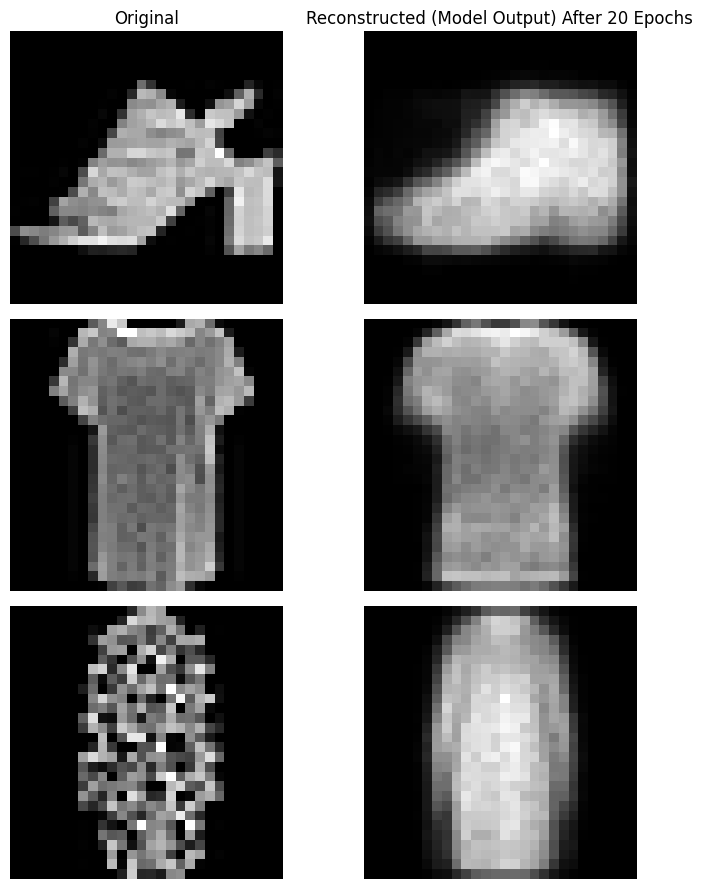


🟢 PHASE 2: Switching to LION...
  Phase 1 Final Loss: 0.019891

  Epoch [  1/80] Loss: 0.019749 | LR: 2.29e-04
  Epoch [  2/80] Loss: 0.019428 | LR: 3.57e-04
  Epoch [  3/80] Loss: 0.019206 | LR: 4.86e-04
  Epoch [  4/80] Loss: 0.018923 | LR: 6.14e-04
  Epoch [  5/80] Loss: 0.018525 | LR: 7.43e-04
  Epoch [  6/80] Loss: 0.018102 | LR: 8.71e-04
  Epoch [  7/80] Loss: 0.017590 | LR: 1.00e-03
  Epoch [  8/80] Loss: 0.017040 | LR: 1.00e-03
  Epoch [  9/80] Loss: 0.016127 | LR: 9.98e-04
  Epoch [ 10/80] Loss: 0.015354 | LR: 9.96e-04
  Epoch [ 11/80] Loss: 0.014734 | LR: 9.93e-04
  Epoch [ 12/80] Loss: 0.014300 | LR: 9.89e-04
  Epoch [ 13/80] Loss: 0.013869 | LR: 9.84e-04
  Epoch [ 14/80] Loss: 0.013552 | LR: 9.78e-04
  Epoch [ 15/80] Loss: 0.013260 | LR: 9.71e-04
  Epoch [ 16/80] Loss: 0.013016 | LR: 9.63e-04
  Epoch [ 17/80] Loss: 0.012802 | LR: 9.55e-04
  Epoch [ 18/80] Loss: 0.012610 | LR: 9.46e-04
  Epoch [ 19/80] Loss: 0.012396 | LR: 9.35e-04
  Epoch [ 20/80] Loss: 0.012232 | LR: 9.25

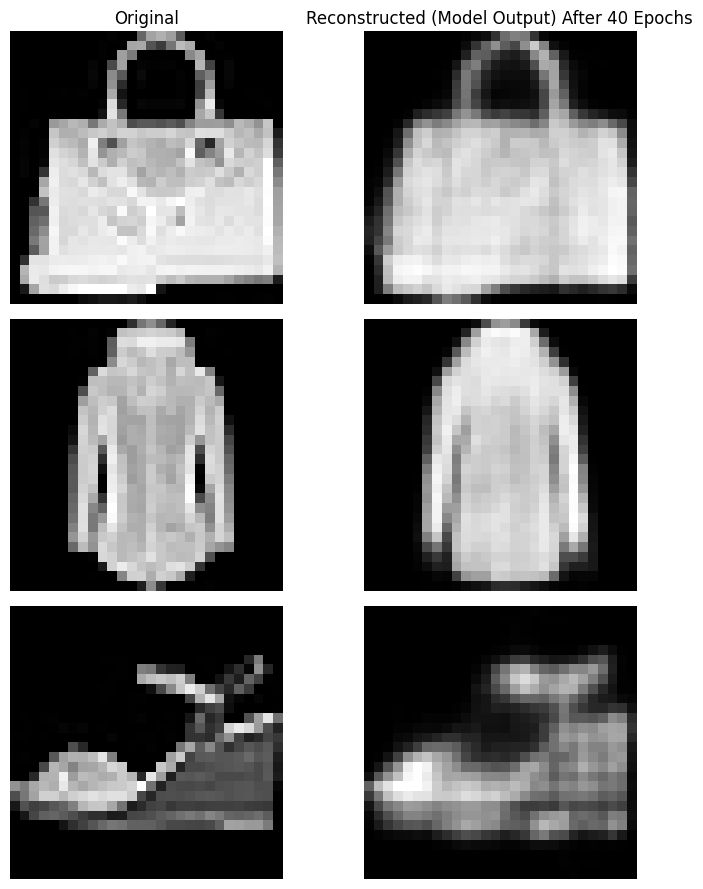

  Epoch [ 21/80] Loss: 0.012069 | LR: 9.13e-04
  Epoch [ 22/80] Loss: 0.011941 | LR: 9.00e-04
  Epoch [ 23/80] Loss: 0.011806 | LR: 8.87e-04
  Epoch [ 24/80] Loss: 0.011663 | LR: 8.73e-04
  Epoch [ 25/80] Loss: 0.011553 | LR: 8.59e-04
  Epoch [ 26/80] Loss: 0.011427 | LR: 8.44e-04
  Epoch [ 27/80] Loss: 0.011299 | LR: 8.28e-04
  Epoch [ 28/80] Loss: 0.011181 | LR: 8.11e-04
  Epoch [ 29/80] Loss: 0.011093 | LR: 7.94e-04
  Epoch [ 30/80] Loss: 0.010983 | LR: 7.77e-04
  Epoch [ 31/80] Loss: 0.010873 | LR: 7.59e-04
  Epoch [ 32/80] Loss: 0.010784 | LR: 7.40e-04
  Epoch [ 33/80] Loss: 0.010681 | LR: 7.21e-04
  Epoch [ 34/80] Loss: 0.010580 | LR: 7.02e-04
  Epoch [ 35/80] Loss: 0.010485 | LR: 6.82e-04
  Epoch [ 36/80] Loss: 0.010406 | LR: 6.62e-04
  Epoch [ 37/80] Loss: 0.010326 | LR: 6.42e-04
  Epoch [ 38/80] Loss: 0.010245 | LR: 6.21e-04
  Epoch [ 39/80] Loss: 0.010157 | LR: 6.00e-04
  Epoch [ 40/80] Loss: 0.010070 | LR: 5.79e-04

Visualizing Results...


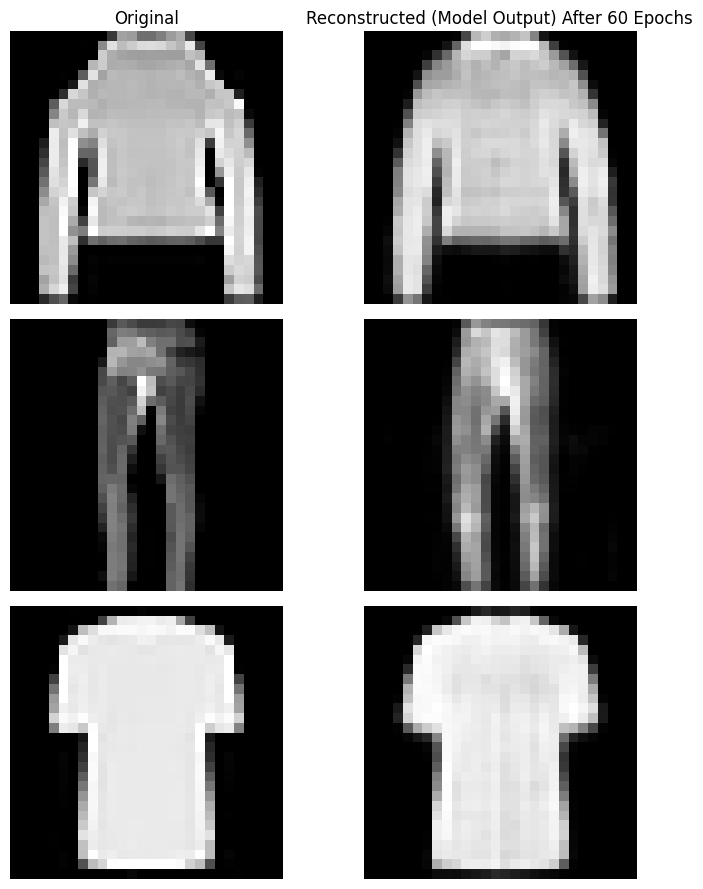

  Epoch [ 41/80] Loss: 0.009993 | LR: 5.58e-04
  Epoch [ 42/80] Loss: 0.009924 | LR: 5.37e-04
  Epoch [ 43/80] Loss: 0.009848 | LR: 5.16e-04
  Epoch [ 44/80] Loss: 0.009779 | LR: 4.94e-04
  Epoch [ 45/80] Loss: 0.009719 | LR: 4.73e-04
  Epoch [ 46/80] Loss: 0.009639 | LR: 4.52e-04
  Epoch [ 47/80] Loss: 0.009574 | LR: 4.31e-04
  Epoch [ 48/80] Loss: 0.009517 | LR: 4.10e-04
  Epoch [ 49/80] Loss: 0.009450 | LR: 3.89e-04
  Epoch [ 50/80] Loss: 0.009390 | LR: 3.68e-04
  Epoch [ 51/80] Loss: 0.009333 | LR: 3.48e-04
  Epoch [ 52/80] Loss: 0.009276 | LR: 3.28e-04
  Epoch [ 53/80] Loss: 0.009222 | LR: 3.08e-04
  Epoch [ 54/80] Loss: 0.009172 | LR: 2.89e-04
  Epoch [ 55/80] Loss: 0.009119 | LR: 2.70e-04
  Epoch [ 56/80] Loss: 0.009076 | LR: 2.51e-04
  Epoch [ 57/80] Loss: 0.009030 | LR: 2.33e-04
  Epoch [ 58/80] Loss: 0.008988 | LR: 2.16e-04
  Epoch [ 59/80] Loss: 0.008948 | LR: 1.99e-04
  Epoch [ 60/80] Loss: 0.008908 | LR: 1.82e-04

Visualizing Results...


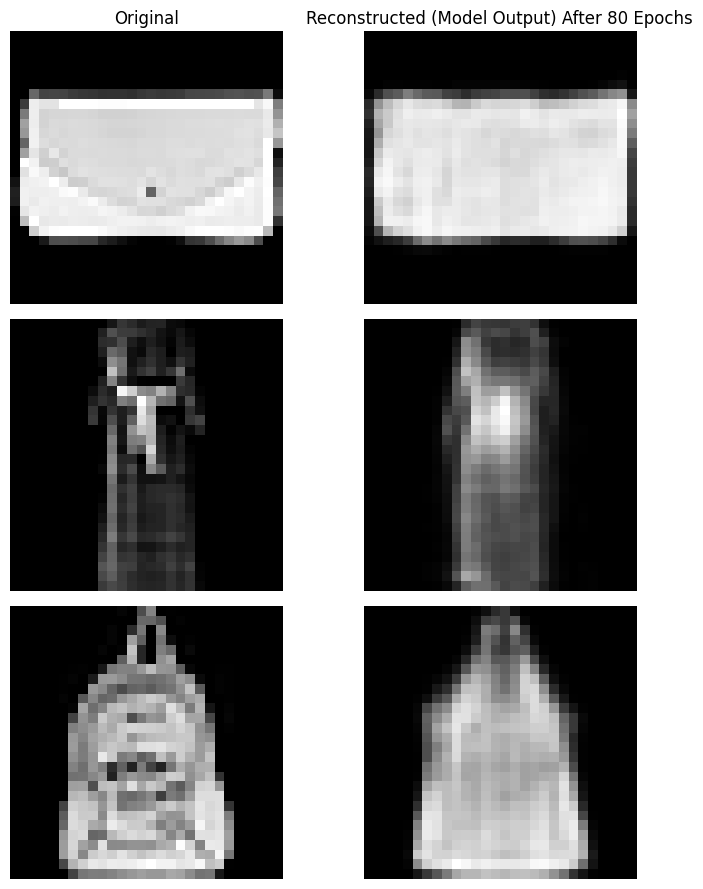

  Epoch [ 61/80] Loss: 0.008871 | LR: 1.66e-04
  Epoch [ 62/80] Loss: 0.008841 | LR: 1.51e-04
  Epoch [ 63/80] Loss: 0.008809 | LR: 1.37e-04
  Epoch [ 64/80] Loss: 0.008782 | LR: 1.23e-04
  Epoch [ 65/80] Loss: 0.008756 | LR: 1.10e-04
  Epoch [ 66/80] Loss: 0.008729 | LR: 9.72e-05
  Epoch [ 67/80] Loss: 0.008711 | LR: 8.55e-05
  Epoch [ 68/80] Loss: 0.008687 | LR: 7.46e-05
  Epoch [ 69/80] Loss: 0.008670 | LR: 6.44e-05
  Epoch [ 70/80] Loss: 0.008655 | LR: 5.51e-05
  Epoch [ 71/80] Loss: 0.008639 | LR: 4.67e-05
  Epoch [ 72/80] Loss: 0.008628 | LR: 3.90e-05
  Epoch [ 73/80] Loss: 0.008623 | LR: 3.23e-05
  Epoch [ 74/80] Loss: 0.008608 | LR: 2.64e-05
  Epoch [ 75/80] Loss: 0.008600 | LR: 2.14e-05
  Epoch [ 76/80] Loss: 0.008595 | LR: 1.73e-05
  Epoch [ 77/80] Loss: 0.008585 | LR: 1.41e-05
  Epoch [ 78/80] Loss: 0.008581 | LR: 1.18e-05
  Epoch [ 79/80] Loss: 0.008578 | LR: 1.05e-05
  Epoch [ 80/80] Loss: 0.008573 | LR: 1.00e-05

Visualizing Results...


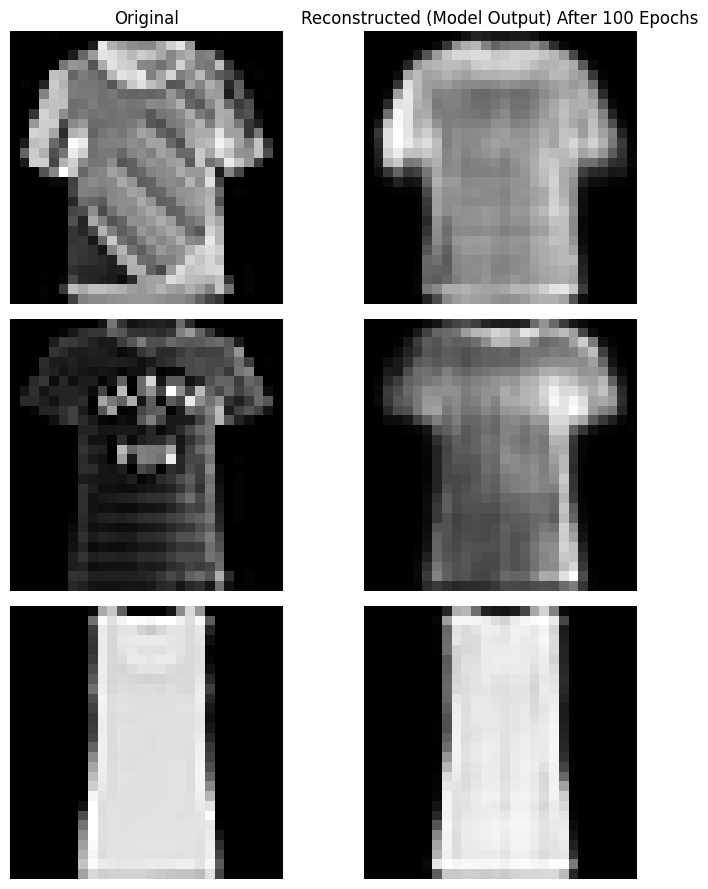


Training Complete!
  Total Time: 116.52s
  Final Loss: 0.008573
  Improvement: 85.44%


In [27]:
model = Autoencoder()
criterion = nn.MSELoss()

# Best configuration parameters
best_config = {
    'phase1_optimizer': 'adagrad',
    'phase2_optimizer': 'lion',
    'phase1_ratio': 0.2,
    'phase1_lr': 1.5e-2,
    'phase2_lr': 1e-3,
    'weight_decay': 0,
    'epochs': 100
}

trained_model, losses, phase_markers = train_sequential_optimizers(
    model=model,
    criterion=criterion,
    train_loader=train_loader,  # Using the NORMAL dataloader
    epochs=best_config['epochs'],
    phase1_optimizer=best_config['phase1_optimizer'],
    phase2_optimizer=best_config['phase2_optimizer'],
    phase1_ratio=best_config['phase1_ratio'],
    phase1_lr=best_config['phase1_lr'],
    phase2_lr=best_config['phase2_lr'],
    weight_decay=best_config['weight_decay'],
    verbose=True
)

### Loss Curves Over Epochs

/tmp/ipython-input-1737787304.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


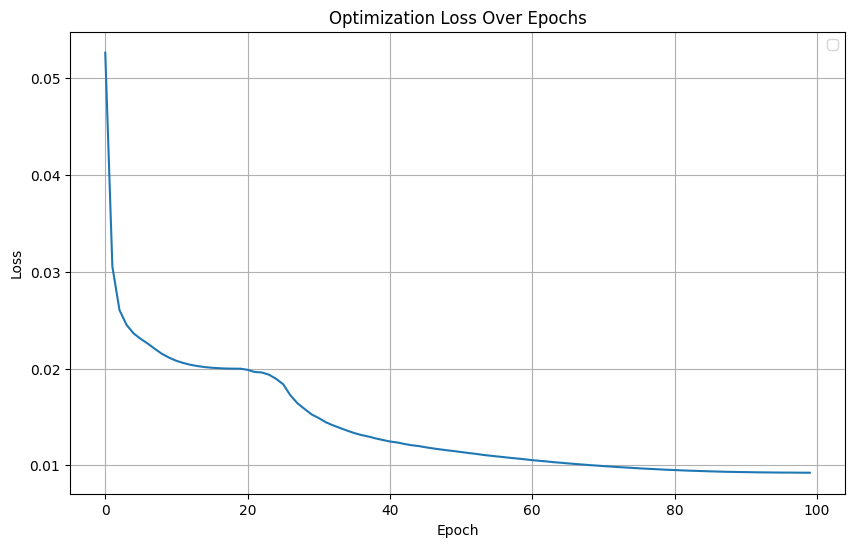

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimization Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### Visual Comparison of Optimized Images


Visualizing Results...


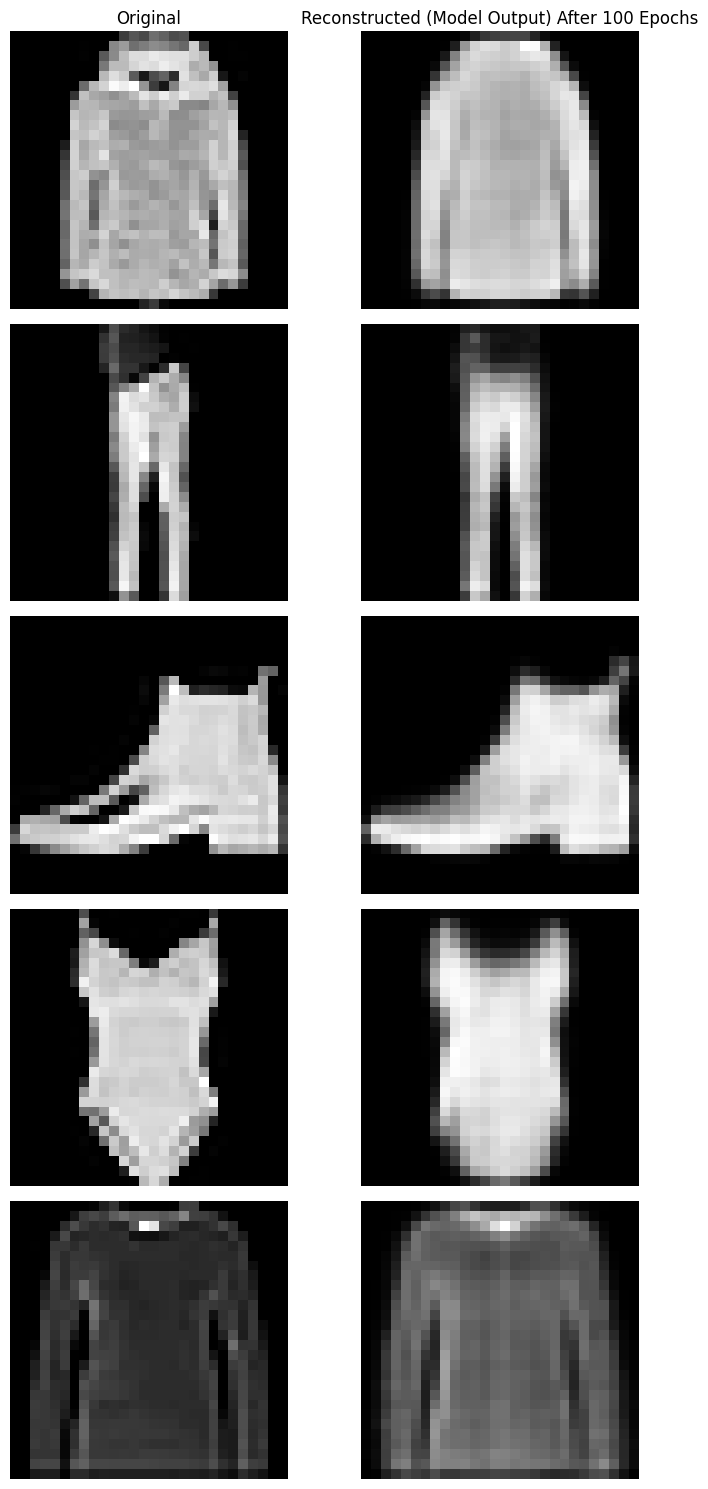

In [15]:


# Visualizing example results after end of training, do 5 examples or change count
data_iter = iter(train_loader)
sample_images = next(data_iter)[0]
show_model_reconstructions(trained_model, sample_images, count=5)

**Summary & Insights**

In this project, we investigated sequential optimization strategies for training an AutoEncoder on Fashion-MNIST under a fixed model, loss, and oracle framework. Our central insight is that optimizer effectiveness is phase-dependent: magnitude-adaptive methods such as AdaGrad enable rapid and stable early descent (“basin finding”) but tend to stagnate later as the accumulated squared-gradient history grows and the effective learning rate collapses, whereas sign-based methods like Lion provide effective late-stage refinement but can be unstable during initialization if the learning rate is too large. By combining these optimizers in a sequential scheme—switching from AdaGrad to Lion after 20% of the total epochs—and using a warmup → cosine annealing learning-rate schedule in both phases, we achieved a final training loss of 0.008573 (85.44% improvement over the initial loss). These results demonstrate that sequential strategies can significantly outperform single-optimizer baselines by leveraging complementary algorithmic strengths, and that warmup is particularly important when switching to Lion, as it reduces transient instability and improves the final basin reached. Future work would explore adaptive switching criteria based on loss-plateau detection rather than fixed epoch thresholds.

